In [1]:
import numpy as np
import pandas as pd
from scipy.stats import skew
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import scipy.stats as stats

In [2]:
df=pd.read_csv("/Users/lokeshreddy/Desktop/DATA MINING/Final Project/airline_passenger_satisfaction-2.csv")
df

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,129876,Male,28,Returning,Personal,Economy Plus,447,2,3.0,4,...,5,1,4,4,4,5,4,4,4,Neutral or Dissatisfied
129876,129877,Male,41,Returning,Personal,Economy Plus,308,0,0.0,5,...,5,2,5,2,2,4,3,2,5,Neutral or Dissatisfied
129877,129878,Male,42,Returning,Personal,Economy Plus,337,6,14.0,5,...,3,3,4,3,3,4,2,3,5,Neutral or Dissatisfied
129878,129879,Male,50,Returning,Personal,Economy Plus,337,31,22.0,4,...,4,4,5,3,3,4,5,3,5,Satisfied


In [3]:
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [4]:
df['Arrival Delay'].fillna(method='ffill', inplace=True)

In [5]:
df.isnull().sum()

ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment                   0
Baggage Handling                

In [6]:
feature=df[["Departure Delay","Arrival Delay"]]
feature

,Departure Delay,Arrival Delay
0,2,5.0
1,26,39.0
2,0,0.0
3,0,0.0
4,0,1.0
...,...,...
129875,2,3.0
129876,0,0.0
129877,6,14.0
129878,31,22.0


## Step 1: Statistics on departure delay (A8) and arrival delay (A9).

**Here is a link that talks about useful statistics that a data scientist would like to know about an entity. https://towardsdatascience.com/5-useful-statistics-data-scientists-need-to-know-
5b4ac29a7da9**

1a. For features A8 and A9, determine

i. Central tendency measures: mean, mode, and median (for each)

ii. The spread: standard deviation (for each)

iii. Percentiles: the 10th, 50th, 75th and 90th percentiles (for each)

iv. 1st quartile, 3rd quartile, and the median

v. The skewness (for each)

vi. The covariance and correlation between A8 and A9

vii. Plot the two delays on a chart to display their distributions
https://www.webdatarocks.com/blog/best-charts-for-data-distribution/

1b. Based on the above results in 1a, make useful conclusions. This is an important part of
data analysis. It should be an English description that non-mathematically oriented airline
executives can understand.

In [7]:
mean_dep=feature["Departure Delay"].mean()
median_dep=feature["Departure Delay"].median()
mode_dep=feature["Departure Delay"].mode()
print("The mean, median, and mode of Departure Delay are:", mean_dep, median_dep, mode_dep)

The mean, median, and mode of Departure Delay are: 14.713712657838004 0.0 0    0
Name: Departure Delay, dtype: int64


In [8]:
mean_arr=feature["Arrival Delay"].mean()
median_arr=feature["Arrival Delay"].median()
mode_arr=feature["Arrival Delay"].mode()
print("The mean, median, and mode of Arrival Delay are:", mean_arr, median_arr, mode_arr)

The mean, median, and mode of Arrival Delay are: 15.101455189405605 0.0 0    0.0
Name: Arrival Delay, dtype: float64


In [9]:
std_dep=feature["Departure Delay"].std()
std_arr=feature["Arrival Delay"].std()
print("The standard deviation of Departure Delay are:", std_dep)
print("The standard deviation of Arrival Delay are:", std_arr)

The standard deviation of Departure Delay are: 38.07112621501333
The standard deviation of Arrival Delay are: 38.47227554800929


In [10]:
feature.describe()

,Departure Delay,Arrival Delay
count,129880.000000,129880.000000
mean,14.713713,15.101455
std,38.071126,38.472276
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,12.000000,13.000000
max,1592.000000,1584.000000


In [11]:
skew_dep = skew(feature["Departure Delay"])
skew_arr = skew(feature["Arrival Delay"])
print("The skewness of Departure Delay is:", skew_dep)
print("The skewness of Arrival Delay is:", skew_arr)

The skewness of Departure Delay is: 6.821901522036001
The skewness of Arrival Delay is: 6.6606186496913775


In [12]:
percentiles = [10, 50, 75, 90]

departure_delay_percentiles = feature["Departure Delay"].quantile(np.divide(percentiles, 100))
arrival_delay_percentiles = feature["Arrival Delay"].quantile(np.divide(percentiles, 100))

print("Departure Delay:")
print("10th percentile:", departure_delay_percentiles.iloc[0])
print("50th percentile:", departure_delay_percentiles.iloc[1])
print("75th percentile:", departure_delay_percentiles.iloc[2])
print("90th percentile:", departure_delay_percentiles.iloc[3])

print("\nArrival Delay:")
print("10th percentile:", arrival_delay_percentiles.iloc[0])
print("50th percentile:", arrival_delay_percentiles.iloc[1])
print("75th percentile:", arrival_delay_percentiles.iloc[2])
print("90th percentile:", arrival_delay_percentiles.iloc[3])

Departure Delay:
10th percentile: 0.0
50th percentile: 0.0
75th percentile: 12.0
90th percentile: 44.0

Arrival Delay:
10th percentile: 0.0
50th percentile: 0.0
75th percentile: 13.0
90th percentile: 44.0


In [13]:
quartiles = [25, 50, 75]

departure_delay_quartiles = feature["Departure Delay"].quantile(np.divide(quartiles, 100))
arrival_delay_quartiles = feature["Arrival Delay"].quantile(np.divide(quartiles, 100))

print("Departure Delay:")
print("1st quartile:", departure_delay_quartiles.iloc[0])
print("Median:", departure_delay_quartiles.iloc[1])
print("3rd quartile:", departure_delay_quartiles.iloc[2])

print("\nArrival Delay:")
print("1st quartile:", arrival_delay_quartiles.iloc[0])
print("Median:", arrival_delay_quartiles.iloc[1])
print("3rd quartile:", arrival_delay_quartiles.iloc[2])

Departure Delay:
1st quartile: 0.0
Median: 0.0
3rd quartile: 12.0

Arrival Delay:
1st quartile: 0.0
Median: 0.0
3rd quartile: 13.0


In [14]:
feature.skew()

Departure Delay    6.821980
Arrival Delay      6.660696
dtype: float64

In [15]:
feature.cov()

,Departure Delay,Arrival Delay
Departure Delay,1449.410651,1404.284791
Arrival Delay,1404.284791,1480.115986


In [16]:
feature.corr()

,Departure Delay,Arrival Delay
Departure Delay,1.000000,0.958764
Arrival Delay,0.958764,1.000000


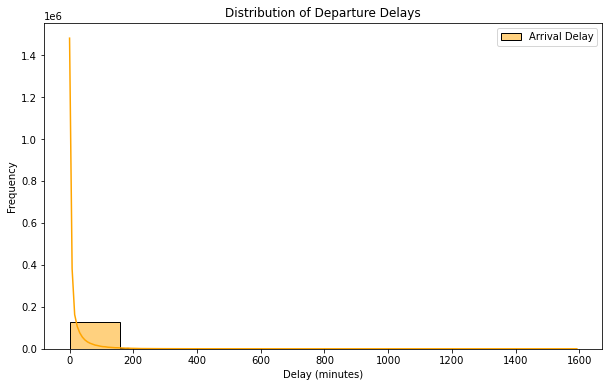

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(feature["Departure Delay"], bins=10, kde=True, label="Arrival Delay", color='orange')
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Departure Delays")
plt.legend()
plt.show()

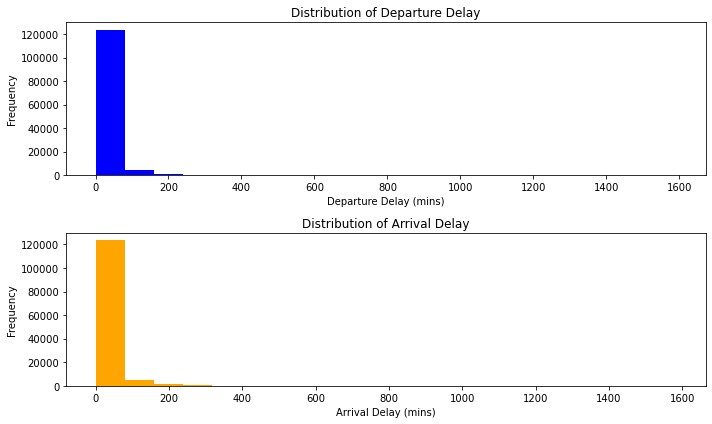

In [18]:
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.hist(feature['Departure Delay'], bins=20, color='blue')
plt.xlabel("Departure Delay (mins)")
plt.ylabel("Frequency")
plt.title("Distribution of Departure Delay")


plt.subplot(2, 1, 2)
plt.hist(feature['Arrival Delay'], bins=20, color='orange')
plt.xlabel("Arrival Delay (mins)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")

plt.tight_layout()
plt.show()

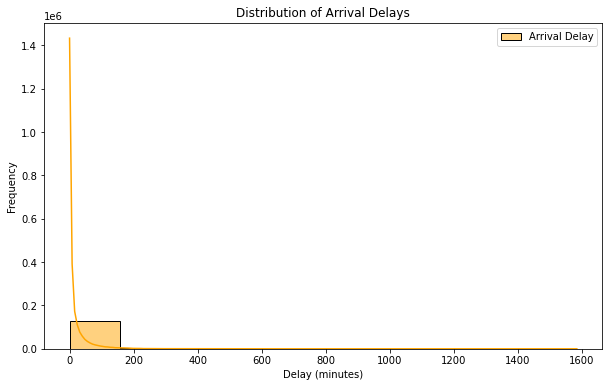

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(feature["Arrival Delay"], bins=10, kde=True, label="Arrival Delay", color='orange')
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delays")
plt.legend()
plt.show()

## Step 2: Convert numerical values to categorical values

a. Discretize age (A3) to nominal values using the following criteria: 0-15: Child; 16-35: Youth; 36-55 Middle age; 56-70: Old; >70- Senior;

b. Discretize flight distance (A7) to nominal values using the following criteria: 0-500 miles: Short haul; 501-3000 miles: Medium haul; >3000 Long haul

c. Discretize delays (A8 and A9) to nominal values: Small: 0-15; Medium: 16-45; Long: >45

d. Plot the distributions for each of the above using the discretized values.

2b. Based on the distributions in 2d, make some useful observations and write them.

In [20]:
disc=pd.read_csv("/Users/lokeshreddy/Desktop/DATA MINING/Final Project/airline_passenger_satisfaction-2 copy.csv")
disc

,Age,Flight Distance,Departure Delay,Arrival Delay
0,Middle age,Medium haul,Small,Small
1,Youth,Medium haul,Medium,Medium
2,Middle age,Medium haul,Small,Small
3,Middle age,Medium haul,Small,Small
4,Middle age,Long haul,Small,Small
...,...,...,...,...
129875,Youth,Short haul,Small,Small
129876,Middle age,Short haul,Small,Small
129877,Middle age,Short haul,Small,Small
129878,Middle age,Short haul,Medium,Medium


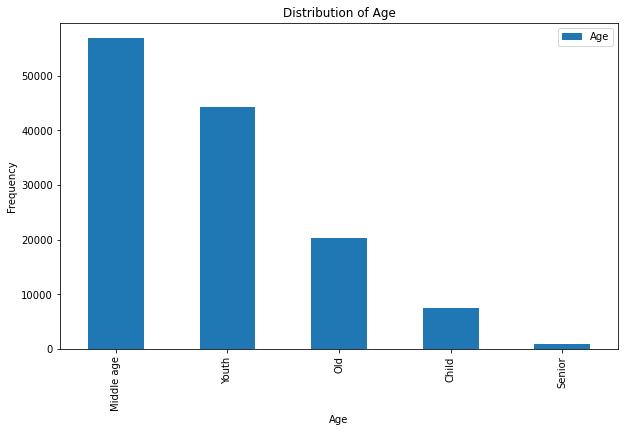

In [21]:
age_counts = disc['Age'].value_counts()
plt.figure(figsize=(10, 6))
age_counts.plot(kind='bar')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.legend()
plt.show()

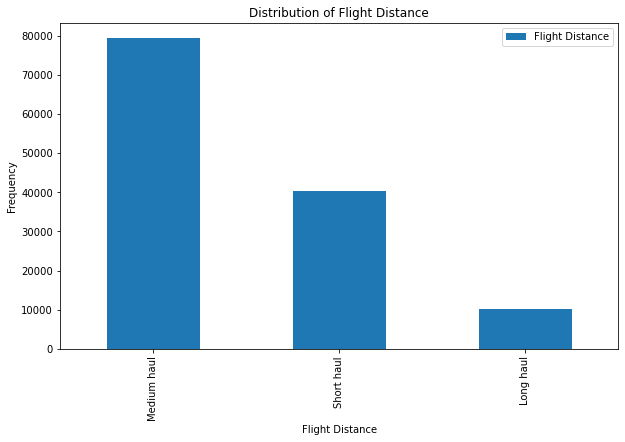

In [22]:
dist_counts = disc['Flight Distance'].value_counts()
plt.figure(figsize=(10, 6))
dist_counts.plot(kind='bar')
plt.xlabel("Flight Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Flight Distance")
plt.legend()
plt.show()

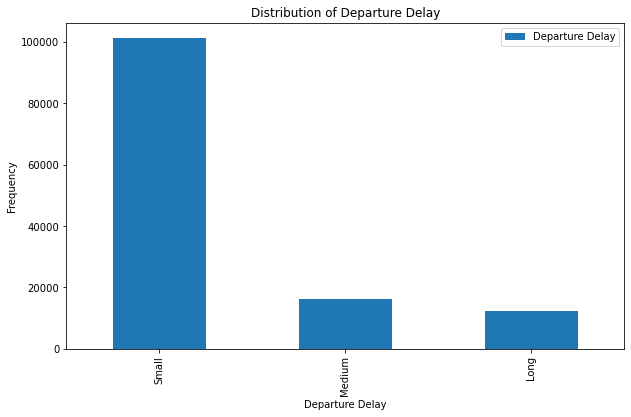

In [23]:
dep_counts = disc['Departure Delay'].value_counts()
plt.figure(figsize=(10, 6))
dep_counts.plot(kind='bar')
plt.xlabel("Departure Delay")
plt.ylabel("Frequency")
plt.title("Distribution of Departure Delay")
plt.legend()
plt.show()

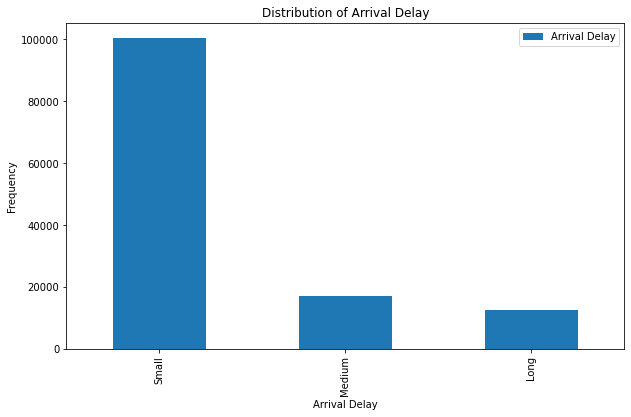

In [24]:
arr_counts = disc['Arrival Delay'].value_counts()
plt.figure(figsize=(10, 6))
arr_counts.plot(kind='bar')
plt.xlabel("Arrival Delay")
plt.ylabel("Frequency")
plt.title("Distribution of Arrival Delay")
plt.legend()
plt.show()

## Step 3. Test the following two hypotheses. Show evidence to show whether they are true or false.

**You may refer to the following URLs for hypothesis testing procedure.
https://vitalflux.com/linear-regression-hypothesis-testing-examples/
https://vitalflux.com/data-science-how-to-formulate-hypothesis-for-hypothesis-testing/**

3H1: Long haul passengers’ overall satisfaction is influenced more by the in-flight service quality than by the departure delays.

3H2. Medium haul passengers’ overall satisfaction is influenced more by the arrival delays than by the in-flight entertainment.

3H3. Make your own hypothesis, state it, and test it.

In [25]:
disc.drop(['Departure Delay', 'Arrival Delay'], axis=1, inplace=True)

In [26]:
hyp = disc.merge(df[['In-flight Service', 'Cleanliness','In-flight Entertainment','Departure Delay','Arrival Delay','Satisfaction']], left_index=True, right_index=True)
hyp

,Age,Flight Distance,In-flight Service,Cleanliness,In-flight Entertainment,Departure Delay,Arrival Delay,Satisfaction
0,Middle age,Medium haul,5,5,5,2,5.0,Neutral or Dissatisfied
1,Youth,Medium haul,5,5,5,26,39.0,Satisfied
2,Middle age,Medium haul,3,5,3,0,0.0,Satisfied
3,Middle age,Medium haul,5,4,5,0,0.0,Satisfied
4,Middle age,Long haul,3,5,3,0,1.0,Satisfied
...,...,...,...,...,...,...,...,...
129875,Youth,Short haul,5,4,4,2,3.0,Neutral or Dissatisfied
129876,Middle age,Short haul,4,2,2,0,0.0,Neutral or Dissatisfied
129877,Middle age,Short haul,4,3,3,6,14.0,Neutral or Dissatisfied
129878,Middle age,Short haul,4,3,3,31,22.0,Satisfied


In [27]:
hyp1 = hyp[hyp['Flight Distance'] == 'Long haul']
hyp1

,Age,Flight Distance,In-flight Service,Cleanliness,In-flight Entertainment,Departure Delay,Arrival Delay,Satisfaction
4,Middle age,Long haul,3,5,3,0,1.0,Satisfied
5,Middle age,Long haul,4,3,4,0,0.0,Satisfied
24,Middle age,Long haul,5,4,5,0,2.0,Satisfied
28,Middle age,Long haul,5,3,5,0,52.0,Satisfied
29,Middle age,Long haul,4,3,4,0,12.0,Satisfied
...,...,...,...,...,...,...,...,...
129728,Youth,Long haul,1,3,1,160,173.0,Neutral or Dissatisfied
129729,Middle age,Long haul,4,2,4,100,94.0,Neutral or Dissatisfied
129746,Youth,Long haul,3,1,1,0,6.0,Neutral or Dissatisfied
129756,Middle age,Long haul,5,1,5,0,0.0,Satisfied


In [28]:
hyp1.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/169054710.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp1.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)


In [29]:
hyp1

,Age,Flight Distance,Inflight_Service,Cleanliness,Inflight_Entertainment,Departure_Delay,Arrival_Delay,Satisfaction
4,Middle age,Long haul,3,5,3,0,1.0,Satisfied
5,Middle age,Long haul,4,3,4,0,0.0,Satisfied
24,Middle age,Long haul,5,4,5,0,2.0,Satisfied
28,Middle age,Long haul,5,3,5,0,52.0,Satisfied
29,Middle age,Long haul,4,3,4,0,12.0,Satisfied
...,...,...,...,...,...,...,...,...
129728,Youth,Long haul,1,3,1,160,173.0,Neutral or Dissatisfied
129729,Middle age,Long haul,4,2,4,100,94.0,Neutral or Dissatisfied
129746,Youth,Long haul,3,1,1,0,6.0,Neutral or Dissatisfied
129756,Middle age,Long haul,5,1,5,0,0.0,Satisfied


In [30]:
label_encoder = LabelEncoder()
hyp1['Overall_Satisfaction'] = label_encoder.fit_transform(hyp1['Satisfaction'])
hyp1

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/1572927044.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp1['Overall_Satisfaction'] = label_encoder.fit_transform(hyp1['Satisfaction'])


,Age,Flight Distance,Inflight_Service,Cleanliness,Inflight_Entertainment,Departure_Delay,Arrival_Delay,Satisfaction,Overall_Satisfaction
4,Middle age,Long haul,3,5,3,0,1.0,Satisfied,1
5,Middle age,Long haul,4,3,4,0,0.0,Satisfied,1
24,Middle age,Long haul,5,4,5,0,2.0,Satisfied,1
28,Middle age,Long haul,5,3,5,0,52.0,Satisfied,1
29,Middle age,Long haul,4,3,4,0,12.0,Satisfied,1
...,...,...,...,...,...,...,...,...,...
129728,Youth,Long haul,1,3,1,160,173.0,Neutral or Dissatisfied,0
129729,Middle age,Long haul,4,2,4,100,94.0,Neutral or Dissatisfied,0
129746,Youth,Long haul,3,1,1,0,6.0,Neutral or Dissatisfied,0
129756,Middle age,Long haul,5,1,5,0,0.0,Satisfied,1


In [31]:
X1 = hyp1[['Inflight_Service', 'Departure_Delay']]
y1 = hyp1['Overall_Satisfaction']

In [32]:
X1 = sm.add_constant(X1)

In [33]:
model1 = sm.OLS(y1, X1).fit()

In [34]:
print("Hypothesis 1 Results:")
print(model1.summary())

Hypothesis 1 Results:
                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.272
Model:                              OLS   Adj. R-squared:                  0.272
Method:                   Least Squares   F-statistic:                     1929.
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:41:49   Log-Likelihood:                -4012.8
No. Observations:                 10313   AIC:                             8032.
Df Residuals:                     10310   BIC:                             8053.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [35]:
model=smf.ols(formula='Overall_Satisfaction~Inflight_Service',data=hyp1)

In [36]:
results=model.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.270
Model:                              OLS   Adj. R-squared:                  0.270
Method:                   Least Squares   F-statistic:                     3818.
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:41:49   Log-Likelihood:                -4027.6
No. Observations:                 10313   AIC:                             8059.
Df Residuals:                     10311   BIC:                             8074.
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           

In [37]:
model1=smf.ols(formula='Overall_Satisfaction~Departure_Delay',data=hyp1)

In [38]:
results=model1.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.007
Model:                              OLS   Adj. R-squared:                  0.007
Method:                   Least Squares   F-statistic:                     69.60
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):           8.18e-17
Time:                          16:41:49   Log-Likelihood:                -5617.2
No. Observations:                 10313   AIC:                         1.124e+04
Df Residuals:                     10311   BIC:                         1.125e+04
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.

In [39]:
model2=smf.ols(formula='Overall_Satisfaction~Inflight_Service+Departure_Delay',data=hyp1)

In [40]:
results=model2.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.272
Model:                              OLS   Adj. R-squared:                  0.272
Method:                   Least Squares   F-statistic:                     1929.
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:41:49   Log-Likelihood:                -4012.8
No. Observations:                 10313   AIC:                             8032.
Df Residuals:                     10310   BIC:                             8053.
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           

In [41]:
coefficients = results.params
p_values = results.pvalues

print("Coefficient Estimates:")
print(coefficients)

print("P-values:")
print(p_values)

Coefficient Estimates:
Intercept           0.070159
Inflight_Service    0.187504
Departure_Delay    -0.000499
dtype: float64
P-values:
Intercept           1.139647e-08
Inflight_Service    0.000000e+00
Departure_Delay     5.807986e-08
dtype: float64


In [42]:
hyp2 = hyp[hyp['Flight Distance'] == 'Medium haul']
hyp2

,Age,Flight Distance,In-flight Service,Cleanliness,In-flight Entertainment,Departure Delay,Arrival Delay,Satisfaction
0,Middle age,Medium haul,5,5,5,2,5.0,Neutral or Dissatisfied
1,Youth,Medium haul,5,5,5,26,39.0,Satisfied
2,Middle age,Medium haul,3,5,3,0,0.0,Satisfied
3,Middle age,Medium haul,5,4,5,0,0.0,Satisfied
6,Middle age,Medium haul,5,4,5,0,0.0,Satisfied
...,...,...,...,...,...,...,...,...
129763,Middle age,Medium haul,4,1,4,0,0.0,Satisfied
129854,Old,Medium haul,3,5,3,0,0.0,Satisfied
129861,Middle age,Medium haul,3,3,3,1,0.0,Satisfied
129863,Middle age,Medium haul,5,3,5,0,0.0,Satisfied


In [43]:
hyp2.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/3439525270.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp2.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)


In [44]:
label_encoder = LabelEncoder()
hyp2['Overall_Satisfaction'] = label_encoder.fit_transform(hyp2['Satisfaction'])
hyp2

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/2057735573.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp2['Overall_Satisfaction'] = label_encoder.fit_transform(hyp2['Satisfaction'])


,Age,Flight Distance,Inflight_Service,Cleanliness,Inflight_Entertainment,Departure_Delay,Arrival_Delay,Satisfaction,Overall_Satisfaction
0,Middle age,Medium haul,5,5,5,2,5.0,Neutral or Dissatisfied,0
1,Youth,Medium haul,5,5,5,26,39.0,Satisfied,1
2,Middle age,Medium haul,3,5,3,0,0.0,Satisfied,1
3,Middle age,Medium haul,5,4,5,0,0.0,Satisfied,1
6,Middle age,Medium haul,5,4,5,0,0.0,Satisfied,1
...,...,...,...,...,...,...,...,...,...
129763,Middle age,Medium haul,4,1,4,0,0.0,Satisfied,1
129854,Old,Medium haul,3,5,3,0,0.0,Satisfied,1
129861,Middle age,Medium haul,3,3,3,1,0.0,Satisfied,1
129863,Middle age,Medium haul,5,3,5,0,0.0,Satisfied,1


In [45]:
model=smf.ols(formula='Overall_Satisfaction~Inflight_Entertainment+Arrival_Delay',data=hyp2)

In [46]:
results=model.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.162
Model:                              OLS   Adj. R-squared:                  0.162
Method:                   Least Squares   F-statistic:                     7689.
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:41:50   Log-Likelihood:                -49957.
No. Observations:                 79291   AIC:                         9.992e+04
Df Residuals:                     79288   BIC:                         9.995e+04
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercep

In [47]:
coefficients = results.params
p_values = results.pvalues

print("Coefficient Estimates:")
print(coefficients)

print("P-values:")
print(p_values)

Coefficient Estimates:
Intercept                -0.051654
Inflight_Entertainment    0.148993
Arrival_Delay            -0.000524
dtype: float64
P-values:
Intercept                 2.582786e-31
Inflight_Entertainment    0.000000e+00
Arrival_Delay             1.429505e-37
dtype: float64


In [48]:
hyp3 = hyp[hyp['Flight Distance'] == 'Short haul']
hyp3

,Age,Flight Distance,In-flight Service,Cleanliness,In-flight Entertainment,Departure Delay,Arrival Delay,Satisfaction
11,Youth,Short haul,3,1,1,20,21.0,Neutral or Dissatisfied
12,Youth,Short haul,4,5,5,16,30.0,Neutral or Dissatisfied
30,Youth,Short haul,4,2,2,0,0.0,Neutral or Dissatisfied
31,Youth,Short haul,4,3,3,0,0.0,Satisfied
32,Youth,Short haul,5,2,2,22,28.0,Neutral or Dissatisfied
...,...,...,...,...,...,...,...,...
129875,Youth,Short haul,5,4,4,2,3.0,Neutral or Dissatisfied
129876,Middle age,Short haul,4,2,2,0,0.0,Neutral or Dissatisfied
129877,Middle age,Short haul,4,3,3,6,14.0,Neutral or Dissatisfied
129878,Middle age,Short haul,4,3,3,31,22.0,Satisfied


In [49]:
hyp3.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/952868626.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp3.rename(columns={'In-flight Entertainment': 'Inflight_Entertainment', 'Departure Delay': 'Departure_Delay', 'In-flight Service': 'Inflight_Service', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)


In [50]:
label_encoder = LabelEncoder()
hyp3['Overall_Satisfaction'] = label_encoder.fit_transform(hyp3['Satisfaction'])
hyp3

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/215721962.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hyp3['Overall_Satisfaction'] = label_encoder.fit_transform(hyp3['Satisfaction'])


,Age,Flight Distance,Inflight_Service,Cleanliness,Inflight_Entertainment,Departure_Delay,Arrival_Delay,Satisfaction,Overall_Satisfaction
11,Youth,Short haul,3,1,1,20,21.0,Neutral or Dissatisfied,0
12,Youth,Short haul,4,5,5,16,30.0,Neutral or Dissatisfied,0
30,Youth,Short haul,4,2,2,0,0.0,Neutral or Dissatisfied,0
31,Youth,Short haul,4,3,3,0,0.0,Satisfied,1
32,Youth,Short haul,5,2,2,22,28.0,Neutral or Dissatisfied,0
...,...,...,...,...,...,...,...,...,...
129875,Youth,Short haul,5,4,4,2,3.0,Neutral or Dissatisfied,0
129876,Middle age,Short haul,4,2,2,0,0.0,Neutral or Dissatisfied,0
129877,Middle age,Short haul,4,3,3,6,14.0,Neutral or Dissatisfied,0
129878,Middle age,Short haul,4,3,3,31,22.0,Satisfied,1


In [51]:
model=smf.ols(formula='Overall_Satisfaction~Inflight_Entertainment+Cleanliness',data=hyp3)

In [52]:
results=model.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.102
Model:                              OLS   Adj. R-squared:                  0.102
Method:                   Least Squares   F-statistic:                     2294.
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:41:50   Log-Likelihood:                -24756.
No. Observations:                 40276   AIC:                         4.952e+04
Df Residuals:                     40273   BIC:                         4.954e+04
Df Model:                             2                                         
Covariance Type:              nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercep

In [53]:
coefficients = results.params
p_values = results.pvalues

print("Coefficient Estimates:")
print(coefficients)

print("P-values:")
print(p_values)

Coefficient Estimates:
Intercept                -0.014007
Inflight_Entertainment    0.120788
Cleanliness              -0.013500
dtype: float64
P-values:
Intercept                 2.214190e-02
Inflight_Entertainment    0.000000e+00
Cleanliness               5.380089e-08
dtype: float64


## Step 5. Reduce the satisfaction features using PCA. 
(https://www.youtube.com/watch?v=zuoMjUAPihA
https://www.youtube.com/watch?v=THA8zBR64Kk )

5a. Using PCA (Principal Component Analysis), combine features A10-A23 into a single feature. Let us call it PCAS. Now find average, minimum, and maximum of A10-A23 (computed for each passenger record). Let us call them AVES, MINS, and MAXS, respectively. Convert A24 (overall satisfaction) into a numeric value by converting neutral or unsatisfied to 1.0 and satisfied to 4. Let us call it DA24.

5b. Which among PCAS, AVES, MINS, and MAXS could be used as proxy (or proxies) for DA24? You need to make some runs to answer this question.

5c. What benefit, if any, is derived by using PCAS from A10-A23? Is there any additional benefit if we had derived three components from PCA instead of just one? Show some evidence to justify your answer. (Hint: Repeat PCA in 5a with 3 components and then answer the question.)

In [54]:
pc=df[['Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling']]
pc

,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
0,3,3,4,3,3,3,5,2,5,5,5,3,5,5
1,2,2,3,5,2,5,4,5,5,3,5,2,5,5
2,4,4,4,5,4,3,5,3,5,5,3,4,3,3
3,2,2,3,4,2,5,5,5,4,4,5,2,5,5
4,3,3,3,5,3,3,4,4,5,4,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
129875,4,4,4,4,2,5,1,4,4,4,5,4,4,4
129876,5,3,5,3,4,5,2,5,2,2,4,3,2,5
129877,5,2,4,2,1,3,3,4,3,3,4,2,3,5
129878,4,4,3,4,1,4,4,5,3,3,4,5,3,5


In [55]:
scaler=StandardScaler()
scaler.fit(pc)
standardized_data=scaler.transform(pc)

In [56]:
pca=PCA(n_components=1)

In [57]:
pca.fit(standardized_data)

PCA(n_components=1)

In [58]:
pca.explained_variance_

array([3.79720954])

In [59]:
pca.components_

array([[-0.10052275, -0.16356808, -0.18185138, -0.2810387 , -0.06573268,
        -0.27761463, -0.34519421, -0.2229702 , -0.35652701, -0.30731637,
        -0.26633397, -0.23552875, -0.42839602, -0.26331914]])

In [60]:
PCAS=pca.fit_transform(standardized_data)

In [61]:
feat=pd.DataFrame(PCAS)

In [62]:
feat=feat.rename(columns={0:"PCAS"})

In [63]:
feat['AVES'] = df[['Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling']].mean(axis=1)
feat['MINS'] = df[['Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling']].min(axis=1)
feat['MAXS'] = df[['Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling']].max(axis=1)

In [64]:
feat

,PCAS,AVES,MINS,MAXS
0,-2.237036,3.857143,2,5
1,-2.314195,3.785714,2,5
2,-1.692450,3.928571,3,5
3,-2.327462,3.785714,2,5
4,-0.814373,3.500000,3,5
...,...,...,...,...
129875,-1.430219,3.785714,1,5
129876,-0.021228,3.571429,2,5
129877,0.294096,3.142857,1,5
129878,-1.324229,3.714286,1,5


In [65]:
feat['DA24'] = df['Satisfaction'].replace({'Neutral or Dissatisfied': 1, 'Satisfied': 4})

In [66]:
feat

,PCAS,AVES,MINS,MAXS,DA24
0,-2.237036,3.857143,2,5,1
1,-2.314195,3.785714,2,5,4
2,-1.692450,3.928571,3,5,4
3,-2.327462,3.785714,2,5,4
4,-0.814373,3.500000,3,5,4
...,...,...,...,...,...
129875,-1.430219,3.785714,1,5,1
129876,-0.021228,3.571429,2,5,1
129877,0.294096,3.142857,1,5,1
129878,-1.324229,3.714286,1,5,4


In [67]:
feat.corr()

,PCAS,AVES,MINS,MAXS,DA24
PCAS,1.000000,-0.960973,-0.533692,-0.491267,-0.527628
AVES,-0.960973,1.000000,0.615213,0.505341,0.495315
MINS,-0.533692,0.615213,1.000000,0.172739,0.253225
MAXS,-0.491267,0.505341,0.172739,1.000000,0.324412
DA24,-0.527628,0.495315,0.253225,0.324412,1.000000


In [68]:
X_train, X_test, y_train, y_test = train_test_split(feat[['PCAS', 'AVES', 'MINS', 'MAXS']], feat['DA24'], test_size=0.2, random_state=42)

# Build regression models for each variable
models = {}
for column in ['PCAS', 'AVES', 'MINS', 'MAXS']:
    model = LinearRegression()
    model.fit(X_train[[column]], y_train)
    models[column] = model

# Evaluate model performance
results = {}
for column, model in models.items():
    y_pred = model.predict(X_test[[column]])
    mse = mean_squared_error(y_test, y_pred)
    results[column] = mse

# Compare the results
best_proxy = min(results, key=results.get)
print("Best proxy for DA24: ", best_proxy)

Best proxy for DA24:  PCAS


In [69]:
results

{'PCAS': 1.5900985935748189,
 'AVES': 1.6626484194629385,
 'MINS': 2.0648022255439846,
 'MAXS': 1.982606349499693}

In [70]:
pca=PCA(n_components=3)

In [71]:
pca.fit(standardized_data)

PCA(n_components=3)

In [72]:
pca.explained_variance_

array([3.79720954, 2.3713795 , 2.16901559])

## Step 6.

Using linear regression, model the relationship between (i) flight distance (in miles) and arrival delay (in minutes), and (ii) flight distance (in miles) and departure delay (in minutes). Explain the derived models and their accuracy. State whether such a relationship makes sense based on the derived models.

In [73]:
reg=df[["Flight Distance","Departure Delay","Arrival Delay"]]
reg

,Flight Distance,Departure Delay,Arrival Delay
0,821,2,5.0
1,821,26,39.0
2,853,0,0.0
3,1905,0,0.0
4,3470,0,1.0
...,...,...,...
129875,447,2,3.0
129876,308,0,0.0
129877,337,6,14.0
129878,337,31,22.0


In [74]:
reg.rename(columns={'Flight Distance': 'Flight_Distance', 'Departure Delay': 'Departure_Delay', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/1883321206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reg.rename(columns={'Flight Distance': 'Flight_Distance', 'Departure Delay': 'Departure_Delay', 'Arrival Delay': 'Arrival_Delay'}, inplace=True)


In [75]:
model=smf.ols(formula='Arrival_Delay ~ Flight_Distance',data=reg)

In [76]:
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Arrival_Delay   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4560
Date:                Wed, 26 Jul 2023   Prob (F-statistic):              0.499
Time:                        16:41:53   Log-Likelihood:            -6.5834e+05
No. Observations:              129880   AIC:                         1.317e+06
Df Residuals:                  129878   BIC:                         1.317e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          15.1875      0.166     

In [77]:
x=reg["Flight_Distance"]
y=reg["Arrival_Delay"]
Xt=x[:,np.newaxis]
Yt=y[:,np.newaxis]

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/2814599512.py:3: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Xt=x[:,np.newaxis]
/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/2814599512.py:4: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  Yt=y[:,np.newaxis]


In [78]:
regr=LinearRegression()
regr.fit(Xt,Yt)

LinearRegression()

In [79]:
print("Intercept=", regr.intercept_, "Slope=",regr.coef_[0])

Intercept= [15.18748427] Slope= [-7.22741307e-05]


In [80]:
yhat=regr.predict(Xt)
yhat.T

array([[15.12814721, 15.12814721, 15.12583444, ..., 15.16312789,
        15.16312789, 15.16312789]])

In [81]:
beta0=regr.predict(np.array([[0]]))
beta1=regr.predict(np.array([[1]]))-regr.predict(np.array([[0]]))

In [82]:
b0=beta0[0]
b1=beta1[0]
b0,b1

(array([15.18748427]), array([-7.22741307e-05]))

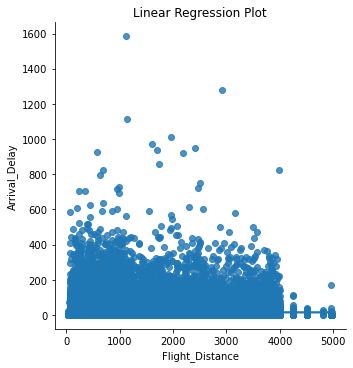

In [83]:
sns.lmplot(x='Flight_Distance', y='Arrival_Delay', data=reg, markers=['o'])

# Set title and axis labels
plt.title('Linear Regression Plot')
plt.xlabel('Flight_Distance')
plt.ylabel('Arrival_Delay')

# Show the plot
plt.show()

In [84]:
model1=smf.ols(formula='Departure_Delay ~ Flight_Distance',data=reg)

In [85]:
results=model1.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:        Departure_Delay   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.7494
Date:                Wed, 26 Jul 2023   Prob (F-statistic):              0.387
Time:                        16:42:00   Log-Likelihood:            -6.5698e+05
No. Observations:              129880   AIC:                         1.314e+06
Df Residuals:                  129878   BIC:                         1.314e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          14.6046      0.164     

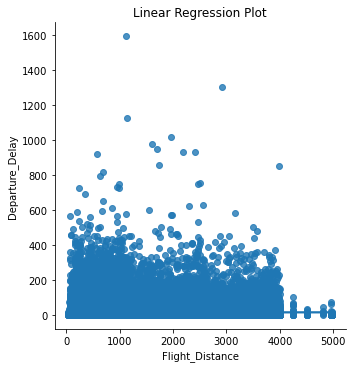

In [86]:
sns.lmplot(x='Flight_Distance', y='Departure_Delay', data=reg, markers=['o'])

# Set title and axis labels
plt.title('Linear Regression Plot')
plt.xlabel('Flight_Distance')
plt.ylabel('Departure_Delay')

# Show the plot
plt.show()

## Step 7. Using any of the data mining techniques you are familiar with, answer the following questions. Show your work to justify your conclusions.

7a. Is satisfaction with seat comfort related (or depends on) to passenger Gender?

7b. Is satisfaction with gate location related to passenger age?

7c. Do first time passengers have more or less expectations than returning customers measured in terms of overall satisfaction?

7d. Is there a distinct (statistically significant) difference between business and personal travelers (A5) in
terms of their reaction to their flights? (Hint: Use any attribute(s) that you think appropriate to measure their reaction.)

7e. Is there a distinct (statistically significant) difference between business class passengers and economy passengers (A6) in terms of their reaction to satisfaction with food-and-drink?

In [87]:
satisfaction_mapping = {
    'Satisfied': 1,
    'Neutral or Dissatisfied': 0,
    # Add more labels and their corresponding numeric values as needed
}

# Apply the mapping to the 'Satisfaction' column
df['Overall_Satisfaction'] = df['Satisfaction'].map(satisfaction_mapping)


In [88]:
t_statistic_seat_gender, p_value_seat_gender = stats.ttest_ind(df[df['Gender'] == 'Male']['Seat Comfort'], df[df['Gender'] == 'Female']['Seat Comfort'])
print("T-statistic for satisfaction with seat comfort and Gender:", t_statistic_seat_gender)
print("P-value for satisfaction with seat comfort and Gender:", p_value_seat_gender)

T-statistic for satisfaction with seat comfort and Gender: -11.089373612558425
P-value for satisfaction with seat comfort and Gender: 1.455122380044486e-28


In [89]:
correlation_coefficient, p_value_gate_age = stats.pearsonr(df['Gate Location'], df['Age'])
print(f"Correlation coefficient for satisfaction with gate location and Age: {correlation_coefficient}")
print(f"P-value for satisfaction with gate location and Age: {p_value_gate_age}")

Correlation coefficient for satisfaction with gate location and Age: -0.00039807576080006115
P-value for satisfaction with gate location and Age: 0.8859264082579607


In [90]:
first_time_passengers = df[df['Customer Type'] == 'First-time']
returning_customers = df[df['Customer Type'] == 'Returning']

# Extract the overall satisfaction scores for each group
first_time_satisfaction = first_time_passengers['Overall_Satisfaction']
returning_satisfaction = returning_customers['Overall_Satisfaction']

# Perform the t-test
t_statistic, p_value = stats.ttest_ind(first_time_satisfaction, returning_satisfaction)
print(f"T-statistic for overall satisfaction and Customer Type: {t_statistic}")
print(f"P-value for overall satisfaction and Customer Type: {p_value}")

# Interpret the results
if p_value < 0.05:
    if t_statistic < 0:
        print("First-time passengers have significantly lower overall satisfaction than returning customers.")
    else:
        print("First-time passengers have significantly higher overall satisfaction than returning customers.")
else:
    print("There is no statistically significant difference in overall satisfaction between first-time passengers and returning customers.")


T-statistic for overall satisfaction and Customer Type: -68.2288056293342
P-value for overall satisfaction and Customer Type: 0.0
First-time passengers have significantly lower overall satisfaction than returning customers.


In [91]:
t_statistic, p_value = stats.ttest_ind(df[df['Type of Travel'] == 'Business']['Overall_Satisfaction'], 
                                       df[df['Type of Travel'] == 'Personal']['Overall_Satisfaction'])
print(f"T-statistic for satisfaction and Type of Travel: {t_statistic}")
print(f"P-value for satisfaction and Type of Travel: {p_value}")

T-statistic for satisfaction and Type of Travel: 181.52943164162733
P-value for satisfaction and Type of Travel: 0.0


In [92]:
t_statistic, p_value = stats.ttest_ind(df[df['Class'] == 'Business']['Food and Drink'], 
                                      df[df['Class'] == 'Economy']['Food and Drink'])
print(f"T-statistic for satisfaction with food-and-drink and Class: {t_statistic}")
print(f"P-value for satisfaction with food-and-drink and Class: {p_value}")


T-statistic for satisfaction with food-and-drink and Class: 31.94600905821368
P-value for satisfaction with food-and-drink and Class: 5.287862406504557e-223


## Step 8.

8a. Determine if any relationship exists between check-in service (A12) and baggage handling (A23) using any data mining technique. Based on this, provide a guidance to airline executives.

8b. Between A10 and A16, which one do you think passengers value the most? Assume that the overall satisfaction (A24) is a good proxy for the v

In [93]:
rel=df[["Baggage Handling","Check-in Service","Departure and Arrival Time Convenience","Seat Comfort","Satisfaction"]]
rel

,Baggage Handling,Check-in Service,Departure and Arrival Time Convenience,Seat Comfort,Satisfaction
0,5,4,3,5,Neutral or Dissatisfied
1,5,3,2,4,Satisfied
2,3,4,4,5,Satisfied
3,5,3,2,5,Satisfied
4,3,3,3,4,Satisfied
...,...,...,...,...,...
129875,4,4,4,1,Neutral or Dissatisfied
129876,5,5,5,2,Neutral or Dissatisfied
129877,5,4,5,3,Neutral or Dissatisfied
129878,5,3,4,4,Satisfied


In [94]:
rel.rename(columns={"Baggage Handling": "Baggage_Handling", "Check-in Service": "Check_in_Service", "Departure and Arrival Time Convenience": 'Departure_and_Arrival_Time_Convenience',"Seat Comfort":"Seat_Comfort"}, inplace=True)

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/3526222434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rel.rename(columns={"Baggage Handling": "Baggage_Handling", "Check-in Service": "Check_in_Service", "Departure and Arrival Time Convenience": 'Departure_and_Arrival_Time_Convenience',"Seat Comfort":"Seat_Comfort"}, inplace=True)


In [95]:
rel

,Baggage_Handling,Check_in_Service,Departure_and_Arrival_Time_Convenience,Seat_Comfort,Satisfaction
0,5,4,3,5,Neutral or Dissatisfied
1,5,3,2,4,Satisfied
2,3,4,4,5,Satisfied
3,5,3,2,5,Satisfied
4,3,3,3,4,Satisfied
...,...,...,...,...,...
129875,4,4,4,1,Neutral or Dissatisfied
129876,5,5,5,2,Neutral or Dissatisfied
129877,5,4,5,3,Neutral or Dissatisfied
129878,5,3,4,4,Satisfied


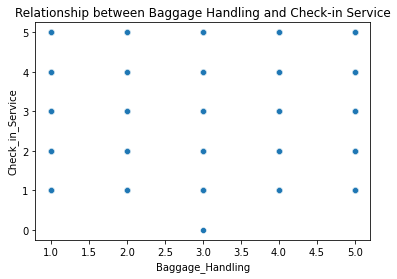

In [96]:
sns.scatterplot(x='Baggage_Handling', y='Check_in_Service', data=rel)

# Set plot labels
plt.xlabel('Baggage_Handling')
plt.ylabel('Check_in_Service')
plt.title('Relationship between Baggage Handling and Check-in Service')

# Show the plot
plt.show()

In [97]:
rel['Check_in_Service'].corr(rel['Baggage_Handling'])

0.23450312820140468

In [98]:
model=smf.ols(formula='Check_in_Service ~ Baggage_Handling',data=rel)

In [99]:
results=model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       Check_in_Service   R-squared:                       0.055
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     7558.
Date:                Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                        16:42:11   Log-Likelihood:            -2.1127e+05
No. Observations:              129880   AIC:                         4.225e+05
Df Residuals:                  129878   BIC:                         4.226e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            2.3923      0.011  

In [100]:
lm=smf.ols('Check_in_Service ~ Baggage_Handling',data=rel).fit()
table=sm.stats.anova_lm(lm)
print(table)

                        df         sum_sq       mean_sq            F  PR(>F)
Baggage_Handling       1.0   11450.666710  11450.666710  7557.832421     0.0
Residual          129878.0  196774.631688      1.515073          NaN     NaN


In [101]:
label_encoder = LabelEncoder()
rel['Overall_Satisfaction'] = label_encoder.fit_transform(rel['Satisfaction'])
rel

/var/folders/mf/k95w0sl124dd8fzv9hjs54kw0000gn/T/ipykernel_44300/3057308397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rel['Overall_Satisfaction'] = label_encoder.fit_transform(rel['Satisfaction'])


,Baggage_Handling,Check_in_Service,Departure_and_Arrival_Time_Convenience,Seat_Comfort,Satisfaction,Overall_Satisfaction
0,5,4,3,5,Neutral or Dissatisfied,0
1,5,3,2,4,Satisfied,1
2,3,4,4,5,Satisfied,1
3,5,3,2,5,Satisfied,1
4,3,3,3,4,Satisfied,1
...,...,...,...,...,...,...
129875,4,4,4,1,Neutral or Dissatisfied,0
129876,5,5,5,2,Neutral or Dissatisfied,0
129877,5,4,5,3,Neutral or Dissatisfied,0
129878,5,3,4,4,Satisfied,1


In [102]:
model1=smf.ols(formula='Overall_Satisfaction ~ Departure_and_Arrival_Time_Convenience',data=rel)

In [103]:
results=model1.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.003
Model:                              OLS   Adj. R-squared:                  0.003
Method:                   Least Squares   F-statistic:                     383.6
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):           2.66e-85
Time:                          16:42:11   Log-Likelihood:                -92949.
No. Observations:                129880   AIC:                         1.859e+05
Df Residuals:                    129878   BIC:                         1.859e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [104]:
model2=smf.ols(formula='Overall_Satisfaction ~ Seat_Comfort',data=rel)

In [105]:
results=model2.fit()
print(results.summary())

                             OLS Regression Results                             
Dep. Variable:     Overall_Satisfaction   R-squared:                       0.122
Model:                              OLS   Adj. R-squared:                  0.122
Method:                   Least Squares   F-statistic:                 1.799e+04
Date:                  Wed, 26 Jul 2023   Prob (F-statistic):               0.00
Time:                          16:42:11   Log-Likelihood:                -84715.
No. Observations:                129880   AIC:                         1.694e+05
Df Residuals:                    129878   BIC:                         1.695e+05
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -0.0166     